**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import joblib

**Load Clean Dataset**

In [2]:
data = pd.read_csv("C:\\Users\\DELL\\IIMSTC-miniProj\\IIMSTC-Cohort10-Urban-AQI-Modeler\\cleaned_air_quality_data (1) (1).csv")

In [3]:
data.head()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,datetime,Hour
0,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,6,4.4,2013-03-01 00:00:00,0
1,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,3,4.7,2013-03-01 01:00:00,1
2,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,6,5.6,2013-03-01 02:00:00,2
3,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,7,3.1,2013-03-01 03:00:00,3
4,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,3,2.0,2013-03-01 04:00:00,4


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301633 entries, 0 to 301632
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PM2.5                  301633 non-null  float64
 1   PM10                   301633 non-null  float64
 2   SO2                    301633 non-null  float64
 3   NO2                    301633 non-null  float64
 4   CO                     301633 non-null  float64
 5   O3                     301633 non-null  float64
 6   TEMP                   301633 non-null  float64
 7   PRES                   301633 non-null  float64
 8   DEWP                   301633 non-null  float64
 9   RAIN                   301633 non-null  float64
 10  WSPM                   301633 non-null  float64
 11  station_Changping      301633 non-null  bool   
 12  station_Dingling       301633 non-null  bool   
 13  station_Dongsi         301633 non-null  bool   
 14  station_Guanyuan       301633 non-nu

**Define Target & Features**

In [4]:
X = data[[
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'month', 'hour'
]]

y = data['PM2.5']

**Train-Test Split**

In [5]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


**Evaluation Function**

In [6]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)


**Linear Regression**

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

**Random Forest**

In [8]:
from sklearn.ensemble import RandomForestRegressor
'''rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)
'''
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

**XGBoost**

In [9]:
import sys
!{sys.executable} -m pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.0/101.7 MB 187.9 kB/s eta 0:09:02
   ---------------------------------------- 0.1/101.7 MB 252.2 kB/s eta 0:06:43
   ---------------------------------------- 0.1/101.7 MB 425.1 kB/s eta 0:03:59
   ---------------------------------------- 0.3/101.7 MB 853.3 kB/s eta 0:01:59
   ---------------------------------------- 0.5/101.7 MB 1.2 MB/s eta 0:01:23
   ---------------------------------------- 0.5/101.7 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 0.7/101.7 MB 1.5 MB/s eta 0:01:07
   ---------------------------------------- 0.8/101.7 MB 1.7 MB/s eta 0:01:01
   ---------------------------------------- 1.0/101.7 MB 1.8 MB/s eta 0:00:

In [11]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

**Model comparison**

In [12]:
evaluate(y_test, pred_lr, "Linear Regression")


Linear Regression
RMSE: 29.988114231973746
MAE : 20.04436863948339
R2  : 0.8518420860356503


In [13]:
evaluate(y_test, pred_rf, "Random Forest")


Random Forest
RMSE: 21.507570483227262
MAE : 13.476393014843051
R2  : 0.9237904756223896


In [14]:
evaluate(y_test, pred_xgb, "XGBoost")

XGBoost
RMSE: 19.051561951374282
MAE : 11.723690726975535
R2  : 0.9402018544130339


**Feature Importance**

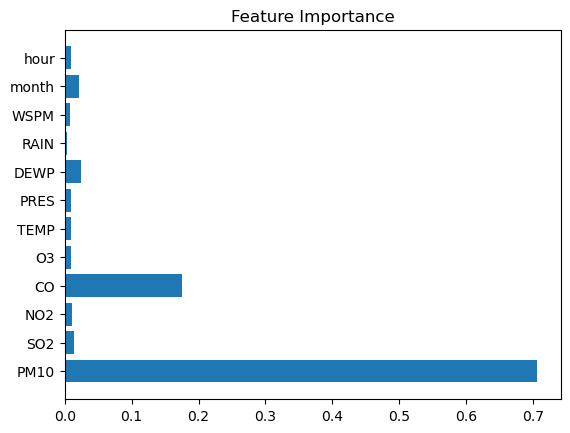

In [15]:
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

**Save Models**

In [20]:
joblib.dump(xgb, r"C:\Users\DELL\IIMSTC-miniProj\IIMSTC-Cohort10-Urban-AQI-Modeler\models\xgb_pm25_model.pkl")

['C:\\Users\\DELL\\IIMSTC-miniProj\\IIMSTC-Cohort10-Urban-AQI-Modeler\\models\\xgb_pm25_model.pkl']

In [22]:
joblib.dump(rf, r"C:\Users\DELL\IIMSTC-miniProj\IIMSTC-Cohort10-Urban-AQI-Modeler\models\rf_pm25_model.pkl")

['C:\\Users\\DELL\\IIMSTC-miniProj\\IIMSTC-Cohort10-Urban-AQI-Modeler\\models\\rf_pm25_model.pkl']